In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import log_loss
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

train = pd.read_csv('/Users/mochidzukimidoriryuu/Desktop/kaggle/titanic/train.csv')
test = pd.read_csv('/Users/mochidzukimidoriryuu/Desktop/kaggle/titanic/test.csv')

train = train.set_index('PassengerId')
test = test.set_index('PassengerId')


df = pd.concat([train, test], axis=0, sort=False)

In [2]:
# Embarkedの欠損値をmodeで埋めてからエンコーディング
if df['Embarked'].isnull().sum() > 0:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    le_embarked = LabelEncoder()
    df['Embarked'] = le_embarked.fit_transform(df['Embarked'].astype(str))

# Sexのエンコーディング
le_sex = LabelEncoder()
df['Sex'] = le_sex.fit_transform(df['Sex'].astype(str))

# 相関行列のヒートマップを描画
# fig, axis = plt.subplots(figsize=(10, 8))
# sns.heatmap(df.corr(), annot=True)
# plt.show()

# Ageの欠損値をPclassとSexの平均で埋める
df['Age'] = df['Age'].fillna(df.groupby(['Pclass', 'Sex'])['Age'].transform('mean'))
df['Age'] = pd.cut(df['Age'], 
                   bins=[0, 12, 18, 35, 60, 100], 
                   labels=[0, 1, 2, 3, 4]).astype(int)
print(df['Age'].head())


# fareの欠損値をPclassとSexの平均で埋める
df['Fare'] = df['Fare'].fillna(df.groupby(['Pclass', 'Sex'])['Fare'].transform('mean'))
cut_Fare = pd.cut(df['Fare'], 4)
df['Fare'] = LabelEncoder().fit_transform(cut_Fare)

# cross_Fare = pd.crosstab(df['Fare'], df['Survived'], normalize='index')
# cross_Fare.plot.bar(figsize=(10, 5))

PassengerId
1    2
2    3
3    2
4    2
5    2
Name: Age, dtype: int64


In [3]:
# cabinの欠損値を埋める
df['Cabin'] = df['Cabin'].apply(lambda x: str(x)[0])
set(df['Cabin'])
df.groupby(df['Cabin'])['Survived'].agg(['mean', 'count'])

df['Cabin'] = LabelEncoder().fit_transform(df['Cabin'])

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/var/folders/hr/vg9y_pz96fzcjb7z0pkvg8hh0000gn/T/ipykernel_39027/2911155722.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract('([A-Za-z]+)\.', expand=False)


<Axes: xlabel='Title'>

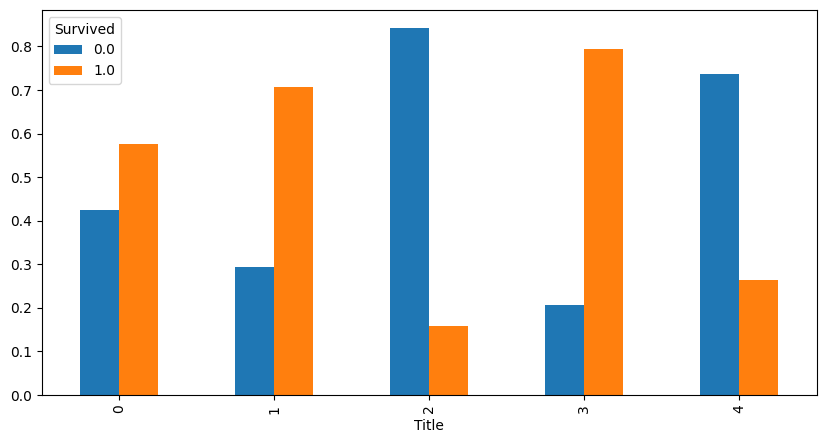

In [4]:
df['Title'] = df['Name'].str.extract('([A-Za-z]+)\.', expand=False)
df['Title'].value_counts()

other_title = ['Dr', 'Rev', 'Col', 'Major', 'Lady', 'Capt', 'Countess', 'Jonkheer']
df['Title'] = df['Title'].replace(['Mlle', 'Ms', 'Mme', 'Lady'], 'Miss')
df['Title'] = df['Title'].replace(['Countess', 'Dona'], 'Mrs')
df['Title'] = df['Title'].replace(['Sir', 'Don'], 'Mr')
df['Title'] = df['Title'].replace(other_title, 'Other')

df.groupby('Title')['Survived'].mean()

df['Title'] = LabelEncoder().fit_transform(df['Title'])

cros_Title = pd.crosstab(df['Title'], df['Survived'], normalize='index')
cros_Title.plot.bar(figsize=(10, 5))

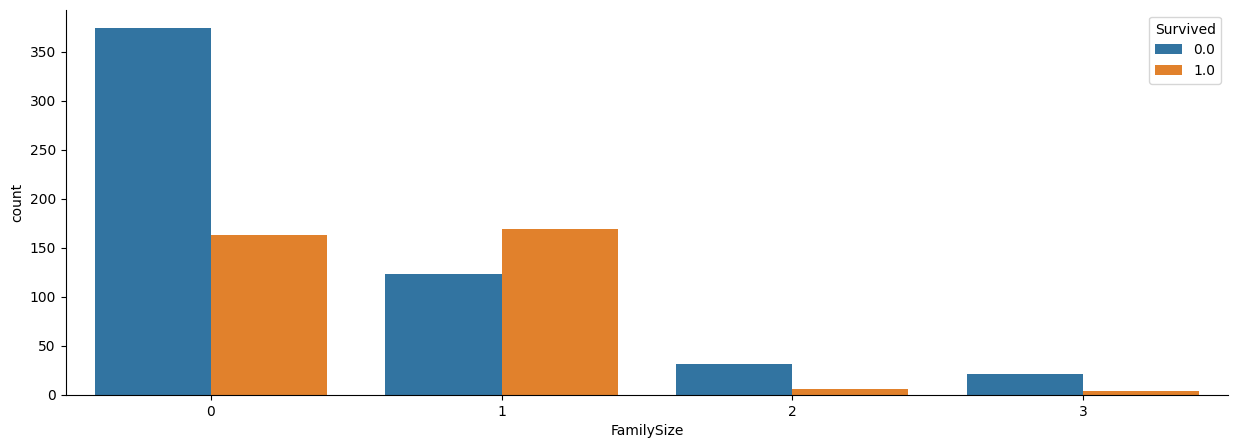

In [5]:
df['FamilySize'] = df['SibSp'] + df['Parch']+1
# df = df.drop(['Sib Sp', 'Parch'], axis=1)

df.loc[df['FamilySize'] == 1, 'FamilySize'] = 0
df.loc[(df['FamilySize'] > 1) & (df['FamilySize'] <= 4), 'FamilySize'] = 1
df.loc[(df['FamilySize'] > 4) & (df['FamilySize'] <= 6), 'FamilySize'] = 2
df.loc[df['FamilySize'] > 6, 'FamilySize'] = 3

fig, axis = plt.subplots(figsize=(15, 5))
sns.countplot(x='FamilySize', hue='Survived', data=df, ax=axis)
sns.despine()



<Axes: xlabel='FamilySize'>

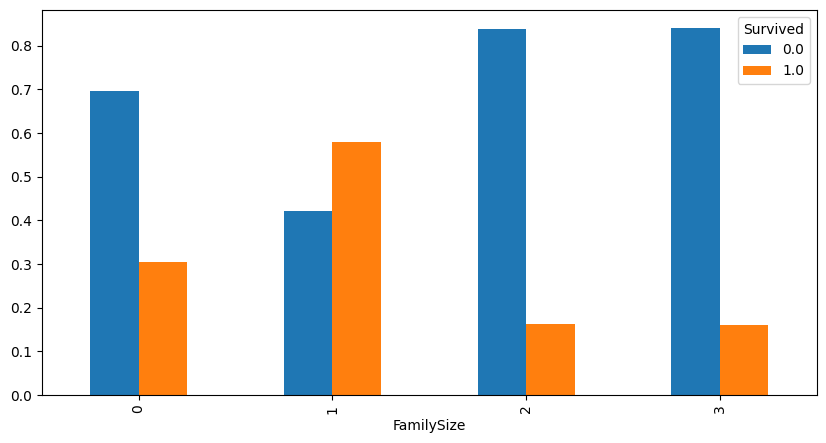

In [6]:
cross_Age = pd.crosstab(df["FamilySize"], df["Survived"], normalize='index')
cross_Age.plot.bar(figsize=(10, 5))

In [7]:
df['Ticket_Prefix'] = df['Ticket'].str.extract('^([A-Za-z./]+)', expand=False)
df['Ticket_Prefix'] = df['Ticket_Prefix'].fillna('NUM')

df['Ticket_Prefix'] = LabelEncoder().fit_transform(df['Ticket_Prefix'])

# df['Ticket_Num'] = df['Ticket'].str.extract(r'(\d+)$', expand=False)
# df['Ticket_Num'] = pd.to_numeric(df['Ticket_Num'], errors='coerce').fillna(0)
# scaler = StandardScaler()
# df['Ticket_Num'] = scaler.fit_transform(df[['Ticket_Num']])
df.drop(['Ticket'], axis=1, inplace=True)

In [8]:
s_mean = df.rename(columns={'Survived': 'S_mean'})
s_count = df.rename(columns={'Survived': 'S_count'})

s_mean = s_mean.groupby(['Sex', 'Age', 'FamilySize'])['S_mean'].mean()
s_count = s_count.groupby(['Sex', 'Age', 'FamilySize'])['S_count'].count()

pd.concat([s_mean, s_count], axis=1)

S_mean  S_count
Sex Age FamilySize                   
0   0   0           1.000000        1
        1           0.809524       21
        2           0.000000        5
        3           0.200000        5
    1   0           0.714286       14
        1           0.789474       19
        2           1.000000        1
        3           0.500000        2
    2   0           0.780488       82
        1           0.757143       70
        2           0.444444        9
        3           0.000000        3
    3   0           0.814815       27
        1           0.886364       44
        2           0.200000        5
        3           0.333333        3
    4   0           1.000000        2
        1           1.000000        1
1   0   0           0.000000        1
        1           1.000000       20
        2           0.000000       10
        3           0.166667        6
    1   0           0.100000       20
        1           0.100000       10
        2           0.000000        3
        3           0.000000        1
    2   0           0.154412      272
        1           0.190476       63
        2           0.000000        2
        3           0.000000        4
    3   0           0.176471      102
        1           0.261905       42
        2           0.000000        1
        3           0.000000        1
    4   0           0.125000       16
        1           0.000000        2
        2           0.000000        1

In [9]:
m_s_mean = df.rename(columns={'Survived': 'S_mean'})
m_s_count = df.rename(columns={'Survived': 'S_count'})

m_s_mean = m_s_mean.groupby(['Sex', 'Age', 'FamilySize', 'Pclass'])['S_mean'].mean().tail(29)
m_s_count = m_s_count.groupby(['Sex', 'Age', 'FamilySize', 'Pclass'])['S_count'].count().tail(29)

pd.concat([m_s_mean, m_s_count], axis=1)

S_mean  S_count
Sex Age FamilySize Pclass                   
1   1   0          3       0.142857       14
        1          1       0.500000        2
                   3       0.000000        8
        2          1            NaN        0
                   3       0.000000        3
        3          3       0.000000        1
    2   0          1       0.588235       17
                   2       0.113636       44
                   3       0.127962      211
        1          1       0.416667       12
                   2       0.052632       19
                   3       0.187500       32
        2          1       0.000000        1
                   3       0.000000        1
        3          3       0.000000        4
    3   0          1       0.285714       49
                   2       0.052632       19
                   3       0.088235       34
        1          1       0.423077       26
                   2       0.000000        8
                   3       0.000000        8
        2          3       0.000000        1
        3          3       0.000000        1
    4   0          1       0.111111        9
                   2       0.333333        3
                   3       0.000000        4
        1          1       0.000000        2
                   2            NaN        0
        2          1       0.000000        1

In [10]:
m_s_mean = df.rename(columns={'Survived': 'S_mean'})
m_s_count = df.rename(columns={'Survived': 'S_count'})

m_s_mean = m_s_mean.groupby(['Sex', 'Age', 'FamilySize', 'Pclass'])['S_mean'].mean().head(27)
m_s_count = m_s_count.groupby(['Sex', 'Age', 'FamilySize', 'Pclass'])['S_count'].count().head(27)

pd.concat([m_s_mean, m_s_count], axis=1)

S_mean  S_count
Sex Age FamilySize Pclass                   
0   0   0          2            NaN        0
                   3       1.000000        1
        1          1       0.000000        1
                   2       1.000000        8
                   3       0.750000       12
        2          3       0.000000        5
        3          3       0.200000        5
    1   0          1       1.000000        1
                   2       1.000000        2
                   3       0.636364       11
        1          1       1.000000        8
                   2       1.000000        4
                   3       0.428571        7
        2          1       1.000000        1
        3          3       0.500000        2
    2   0          1       1.000000       18
                   2       0.947368       19
                   3       0.622222       45
        1          1       0.933333       15
                   2       0.909091       22
                   3       0.575758       33
        2          1       1.000000        3
                   2       1.000000        1
                   3       0.000000        5
        3          3       0.000000        3
    3   0          1       0.928571       14
                   2       0.818182       11

In [11]:
df['TopName'] = df['Name'].map(lambda name: name.split(',')[0].strip())
df['W_C'] = ((df.Title == 0) | (df.Sex == 0))
df['M'] = ~((df.Title == 0) | (df.Sex == 0))
family = df.groupby(['TopName', 'Pclass'])['Survived']

df['F_Total'] = family.transform(lambda s: s.fillna(0).count())
df['F_Total'] = df['F_Total'].mask(df['W_C'], (df['F_Total'] - 1), axis=0)
df['F_Total'] = df['F_Total'].mask(df['M'], (df['F_Total'] - 1), axis=0)

df['F_Survived'] = family.transform(lambda s: s.fillna(0).sum())
df['F_Survived'] = df['F_Survived'].mask(df['W_C'], (df['F_Survived'] - df['Survived'].fillna(0)), axis=0)
df['F_Survived'] = df['F_Survived'].mask(df['M'], (df['F_Survived'] - df['Survived'].fillna(0)), axis=0)

df['F_S_Suc'] = (df['F_Survived'] / df['F_Total'].replace(0, np.nan))
df['F_S_Suc'].fillna(-1, inplace=True)

s_df = df.groupby(['F_S_Suc', 'W_C'])['Survived'].agg(['mean', 'count'])
s_df

df.drop(['W_C', 'M', 'F_Total', 'F_Survived', 'TopName'], axis=1, inplace=True)


/var/folders/hr/vg9y_pz96fzcjb7z0pkvg8hh0000gn/T/ipykernel_39027/1506631397.py:15: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['F_S_Suc'].fillna(-1, inplace=True)


In [12]:
df['PassengerId'] = df.index
df.drop(['Name', 'Embarked'], axis=1, inplace=True)

df = pd.get_dummies(df, columns=['Sex'], drop_first=True)
df = pd.get_dummies(df, columns=['Pclass', 'Fare'])

In [ ]:
train_x = df.loc[train.index].drop('Survived', axis=1)
train_y = df.loc[train.index]['Survived']
test_x = df.loc[test.index].drop('Survived', axis=1)

scores = []
models = []
kf = KFold(n_splits=4, shuffle=True, random_state=42)
for tr_idx, va_idx in kf.split(train_x):
    tr_x, va_x = train_x.iloc[tr_idx], train_x.iloc[va_idx]
    tr_y, va_y = train_y.iloc[tr_idx], train_y.iloc[va_idx]
    lgb_tr = lgb.Dataset(tr_x, tr_y)
    lgb_val = lgb.Dataset(va_x, va_y)

    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'verbosity': -1,
        'random_state': 42, 
        'learning_rate': 0.05
    }

    model = lgb.train(
        params, 
        lgb_tr, 
        valid_sets=[lgb_val],
        num_boost_round=1000,
        callbacks=[lgb.early_stopping(stopping_rounds=50)]
    )

    va_pred = model.predict(va_x)
    score = log_loss(va_y, va_pred)
    scores.append(score)
    models.append(model)

print(f"Average LogLoss: {np.mean(scores)}")

# 6. 予測（全てのモデルの平均をとる：簡易アンサンブル）
preds = np.zeros(len(test_x))
for model in models:
    preds += model.predict(test_x)
preds /= len(models)

# 7. 提出ファイル作成
submission = pd.DataFrame({
    'PassengerId': test.index, 
    'Survived': (preds > 0.5).astype(int)
})

submission.to_csv('submission.csv', index=False)
print("Submission file created!")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[51]	valid_0's binary_logloss: 0.418562
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[40]	valid_0's binary_logloss: 0.430761
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[44]	valid_0's binary_logloss: 0.429639
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[47]	valid_0's binary_logloss: 0.383149
Average LogLoss: 0.4155274957181679
Submission file created!
